In [1]:
import matplotlib.pyplot as plt
import numpy as np

from model_ranking.results import get_summary_results


INFO: P [MainThread] 2025-07-31 11:32:56,925 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


In [3]:
consis_scores, _, NA_perf_scores = get_summary_results(
    ["EPFL"],
    ["EPFL"],
    selected_augmentations={"none": [], "DO": ["a0005", "a001", "a005", "a01", "a02", "a03", "a04", "a05"]},
    consis_keys={"EPFL": "EI_consis"},
    result_folders={"EPFL": "FP_full"},
    source_models={"EPFL": "E_model4"},
    selected_norms={"EPFL": [None]},
    perf_key="hard_f1",
    approach="feature_perturbation_consistency",
    consis_postfix="median",
    perf_postfix="median",
    base_seg_dir="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"
)

Source: EPFL


100%|██████████| 1/1 [00:00<00:00,  3.62it/s]


In [4]:
consis_scores

{'E_to_E': {'norm_Normalize': {'DO': array([0.82810748, 0.82812369, 0.76051879, 0.47925663, 0.25964987,
          0.00406036, 0.00602687, 0.00723396])}}}

In [5]:
NA_perf_scores

{'E_to_E': {'norm_Normalize': 0.8988688588142395}}

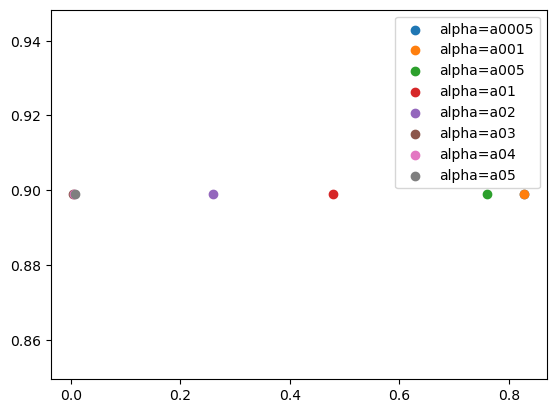

In [10]:
for i, alpha in enumerate(["a0005", "a001", "a005", "a01", "a02", "a03", "a04", "a05"]):
    _ = plt.scatter(
        consis_scores["E_to_E"]["norm_Normalize"]["DO"][i],
        NA_perf_scores["E_to_E"]["norm_Normalize"],
        label=f"alpha={alpha}"
    )
_ = plt.legend()
plt.show()

In [11]:
consis_scores, _, NA_perf_scores = get_summary_results(
    ["Hmito"],
    ["EPFL"],
    selected_augmentations={"none": [], "DO": ["a0001", "a0005", "a001", "a002", "a003", "a004", "a005", "a01"]},
    consis_keys={"EPFL": "EI_consis"},
    result_folders={"EPFL": "FP_full"},
    source_models={"Hmito": "Hm_model_NA2"},
    selected_norms={"EPFL": [None]},
    perf_key="hard_f1",
    approach="feature_perturbation_consistency",
    consis_postfix="median",
    perf_postfix="median",
    base_seg_dir="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"
)

Source: Hmito


100%|██████████| 1/1 [00:00<00:00,  5.71it/s]


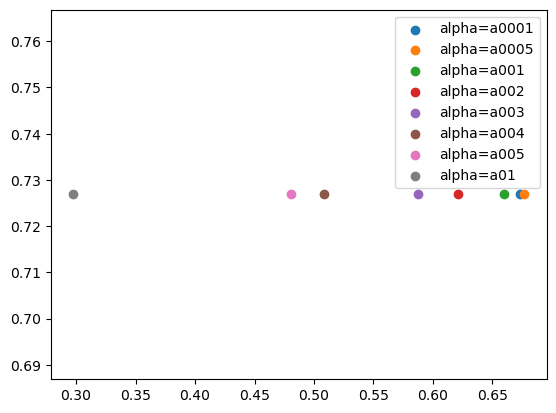

In [13]:
for i, alpha in enumerate(["a0001", "a0005", "a001", "a002", "a003", "a004", "a005", "a01"]):
    _ = plt.scatter(
        consis_scores["Hm_to_E"]["norm_Normalize"]["DO"][i],
        NA_perf_scores["Hm_to_E"]["norm_Normalize"],
        label=f"alpha={alpha}"
    )
_ = plt.legend()
plt.show()

In [ ]:
from pathlib import Path
import shutil

scratch_base = Path("/scratch/talks")
g_base = Path("/g/kreshuk/talks/")
dir_path = Path("consistency_results/patch_segmentation/mitochondria")
combined_path = scratch_base / dir_path

paths = list(combined_path.rglob("**/FP_full"))
for path in paths:
    print(path)
    g_path = Path(str(path).replace(str(scratch_base), str(g_base)))
    print(g_path)
    shutil.copytree(path, g_path, dirs_exist_ok=True)

/scratch/talks/consistency_results/patch_segmentation/mitochondria/Rmito_to_Hmito_gap/feature_perturbation_consistency/FP_full
/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Rmito_to_Hmito_gap/feature_perturbation_consistency/FP_full
/scratch/talks/consistency_results/patch_segmentation/mitochondria/Hmito_to_Rmito_gap/feature_perturbation_consistency/FP_full
/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Hmito_to_Rmito_gap/feature_perturbation_consistency/FP_full
/scratch/talks/consistency_results/patch_segmentation/mitochondria/Hmito_to_EPFL_gap/feature_perturbation_consistency/FP_full
/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Hmito_to_EPFL_gap/feature_perturbation_consistency/FP_full
/scratch/talks/consistency_results/patch_segmentation/mitochondria/Hmito_to_Hmito_gap/feature_perturbation_consistency/FP_full
/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Hmito_to_Hmito_gap/feature_perturbatio

In [ ]:
/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/EPFL_to_EPFL_gap/feature_perturbation_consistency/FP_full